In [1]:
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader

from denoising_diffusion_pytorch import Unet, GaussianDiffusion

from tqdm.auto import tqdm
import csv
import matplotlib.pyplot as plt
import pandas as pd

c:\Users\hynda\OneDrive\Documents\Applied-Deep-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Hyperparameters
LEARNING_RATE = 1e-4
BATCH_SIZE = 256  # Batch size
N_EPOCHS = 120
IMAGE_SIZE = 28
TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# we define a tranform that converts the image to tensor
myTransforms = transforms.Compose([transforms.ToTensor()])

# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = datasets.MNIST(root='dataset/', train=False, download=False, transform=myTransforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


loading MNIST digits dataset


In [4]:
DIM = 32
DIM_MULTS = (1, 2, 5)
model = Unet(
    dim = DIM,
    dim_mults = DIM_MULTS,
    flash_attn = False,
    channels = 1
).to(device)

diffusion = GaussianDiffusion(
    model,
    image_size = IMAGE_SIZE,
    timesteps = TIME_STEPS,           # number of steps
    sampling_timesteps = SAMPLING_TIMESTEPS ,   # number of sampling timesteps (using ddim for faster inference [see ddim paper])
    beta_schedule = 'cosine'
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)


In [5]:
log_file = open('mnist_diffusion_log.csv', 'w', newline='')
writer = csv.writer(log_file)
writer.writerow(['epoch', 'train_loss', 'val_loss'])
snapshots = {}

epochs = tqdm(range(N_EPOCHS))

for epoch in epochs:
    # Training
    diffusion.train()
    train_losses = []
    
    for batch_images, _ in loader:
        batch_images = batch_images.to(device) 
        loss = diffusion(batch_images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
    
    mean_train_loss = sum(train_losses) / len(train_losses)

    # Validation
    diffusion.eval()
    val_losses = []
    with torch.no_grad():
        for batch_images, _ in test_loader:
            batch_images = batch_images.to(device) 
            val_loss = diffusion(batch_images)
            val_losses.append(val_loss.item())

    mean_val_loss = sum(val_losses) / len(val_losses)

    # Logging
    writer.writerow([epoch, mean_train_loss, mean_val_loss])
    log_file.flush()
    epochs.set_postfix(train_loss=mean_train_loss, val_loss=mean_val_loss)

    if epoch % 20 == 0 or epoch == N_EPOCHS - 1:
        diffusion.eval()
        with torch.no_grad():
            sampled_images = diffusion.sample(batch_size=64)
        snapshots[epoch] = sampled_images.cpu()

log_file.close()

100%|██████████| 120/120 [2:50:13<00:00, 85.11s/it, train_loss=0.0368, val_loss=0.0373]


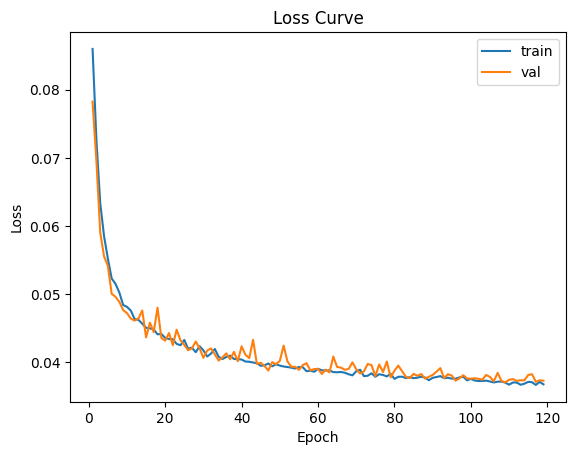

In [6]:
log = pd.read_csv('mnist_diffusion_log.csv')

fig, ax = plt.subplots()
ax.plot(log['epoch'][1:], log['train_loss'][1:], label='train')
ax.plot(log['epoch'][1:], log['val_loss'][1:], label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')
ax.legend()
plt.savefig("plots/loss_curve.png", dpi=300)
plt.show()

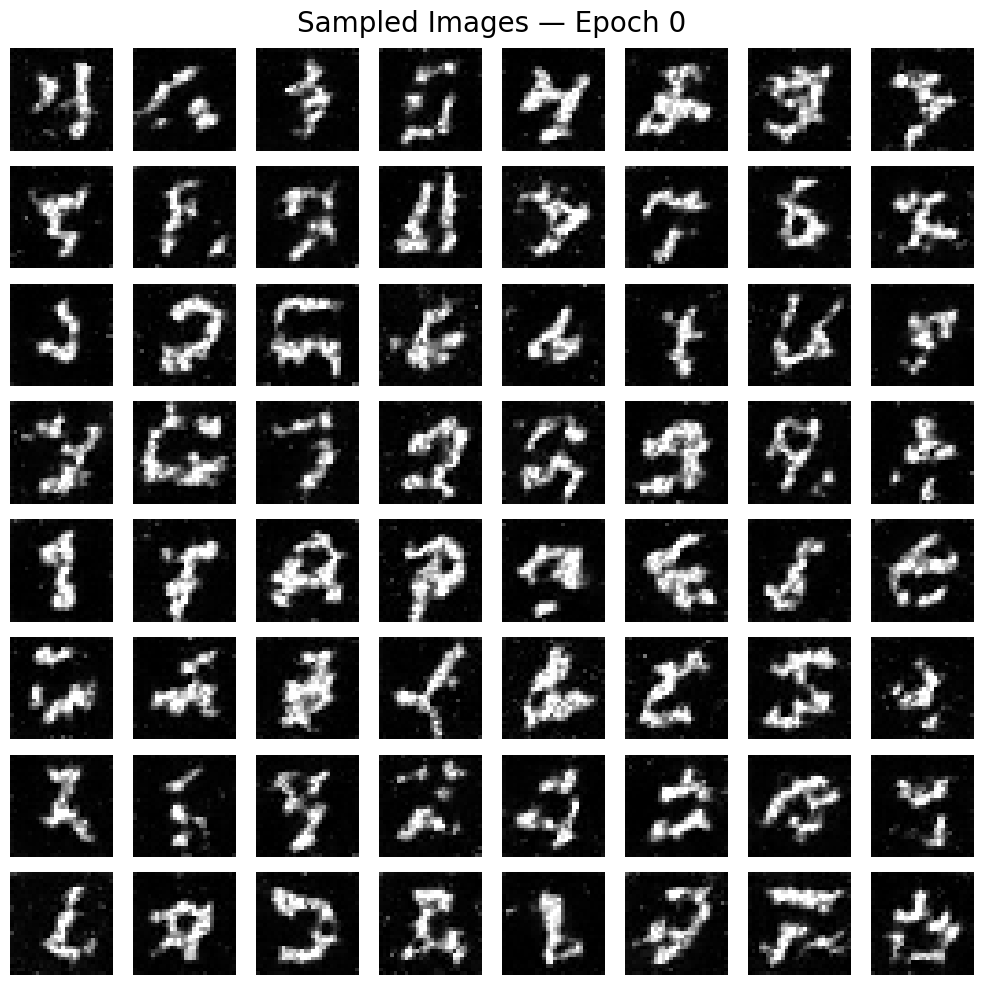

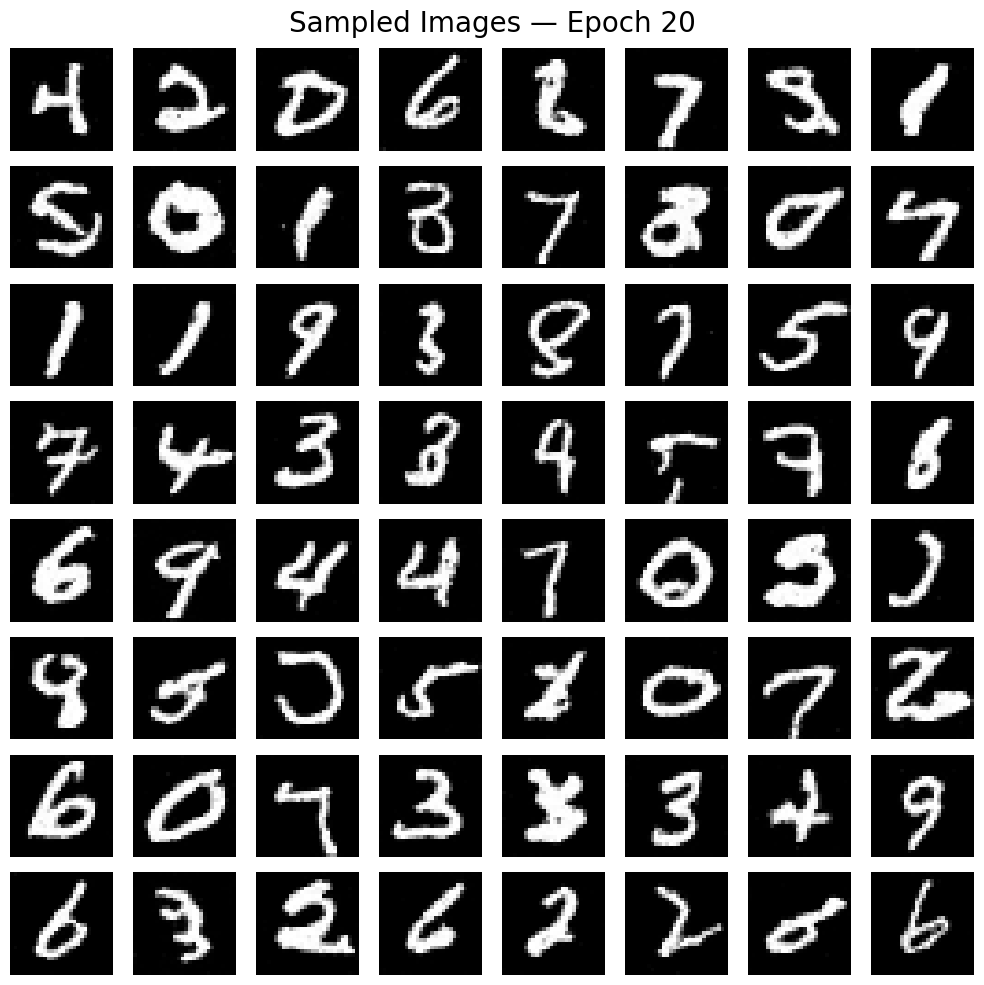

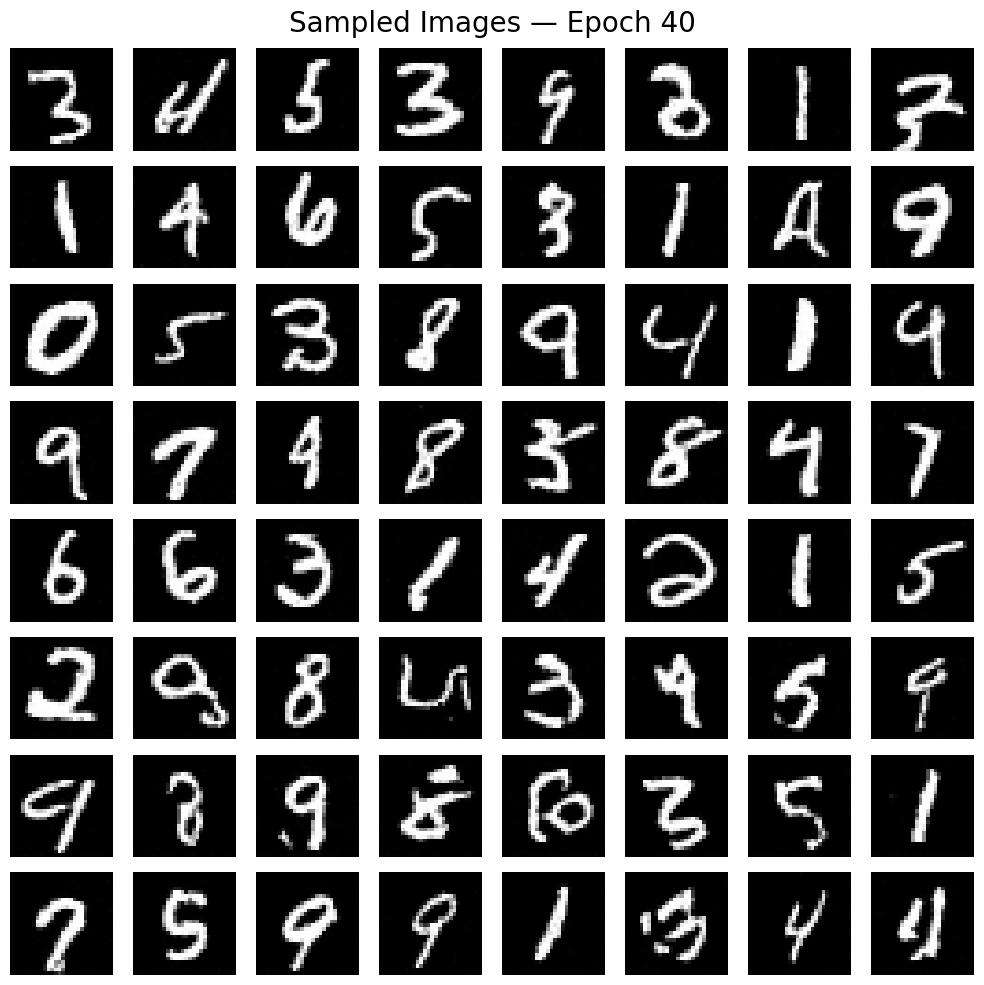

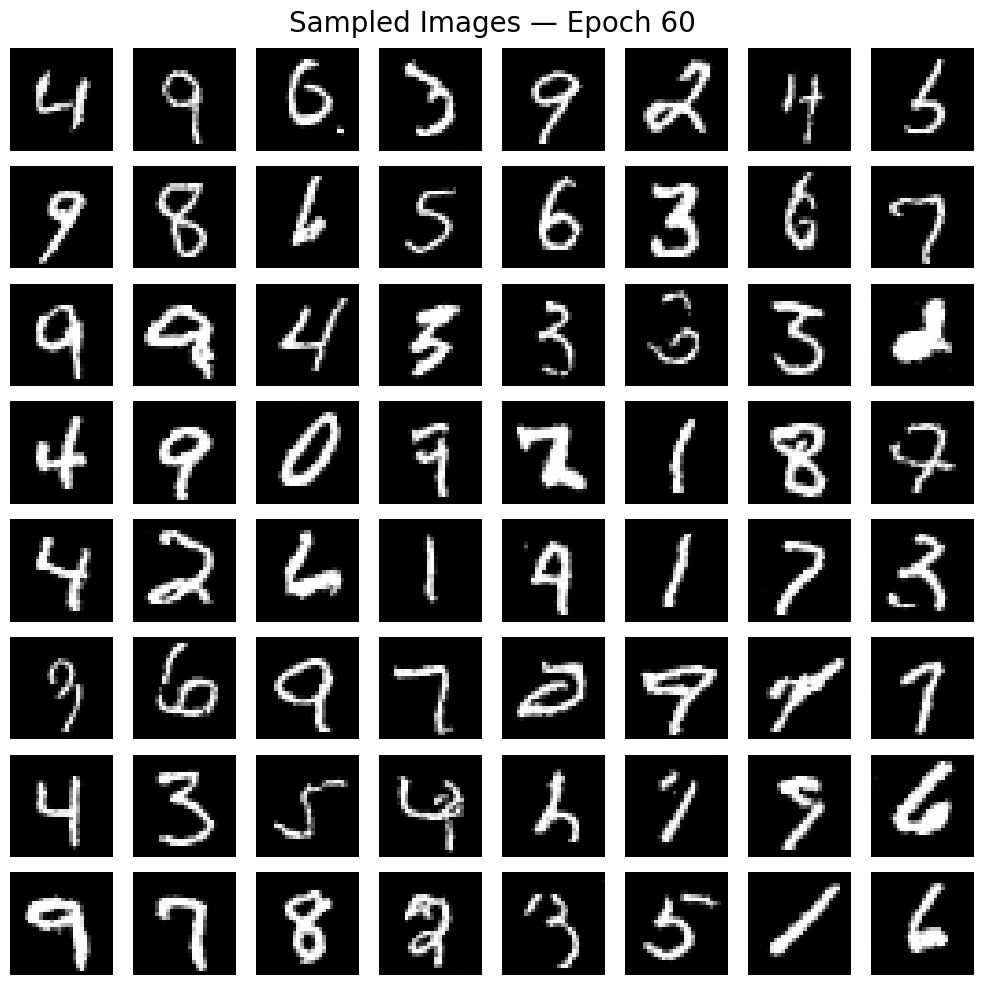

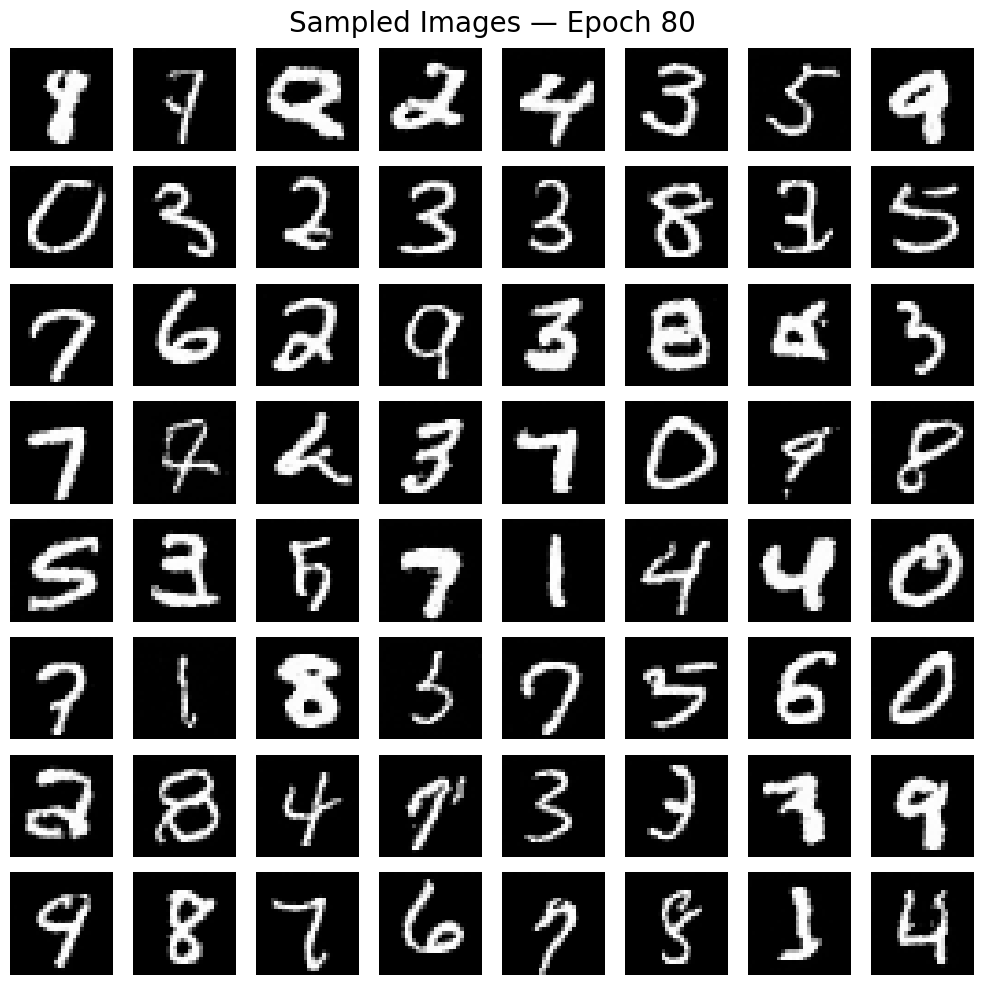

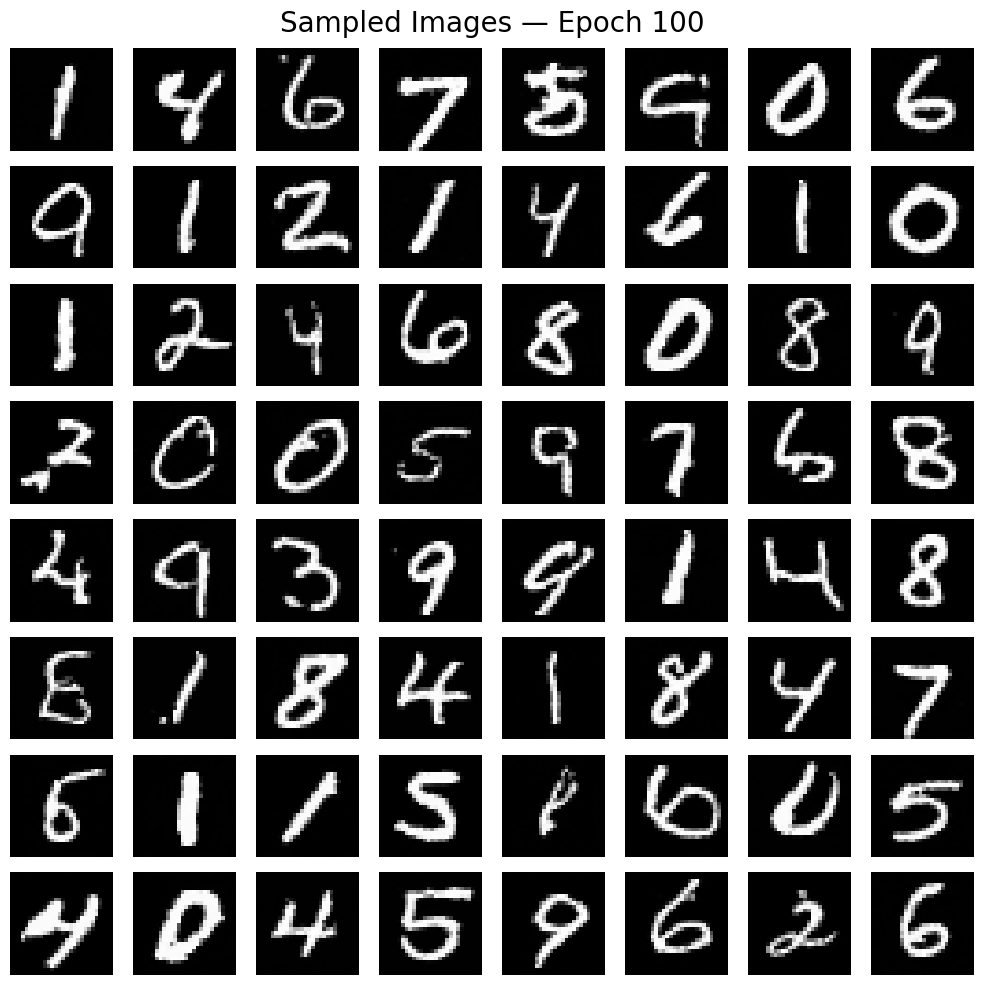

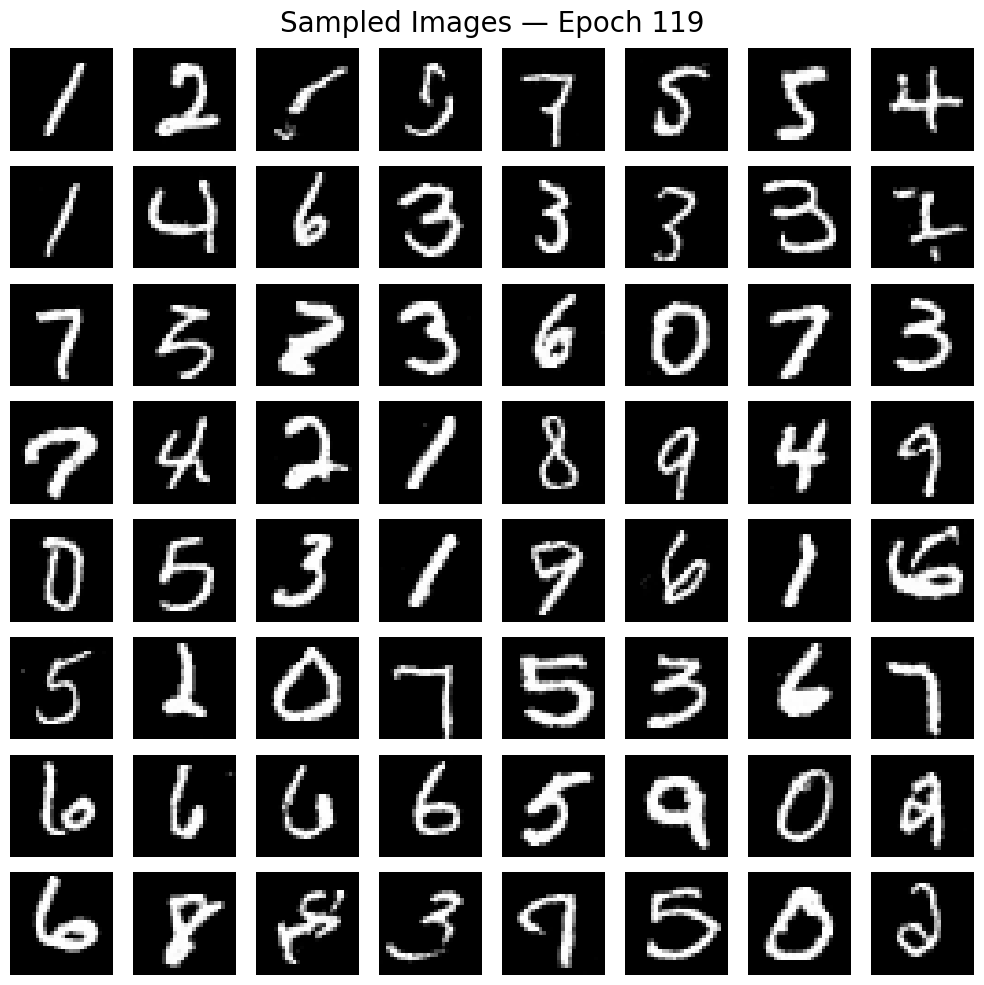

In [7]:
for ep, sampled_images in sorted(snapshots.items()):
    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(sampled_images[i].squeeze().numpy(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Sampled Images — Epoch {ep}', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'plots/sampled_images_epoch_{ep:04d}.png', dpi=300)
    plt.show()

sampling loop time step: 100%|██████████| 250/250 [00:08<00:00, 29.42it/s]


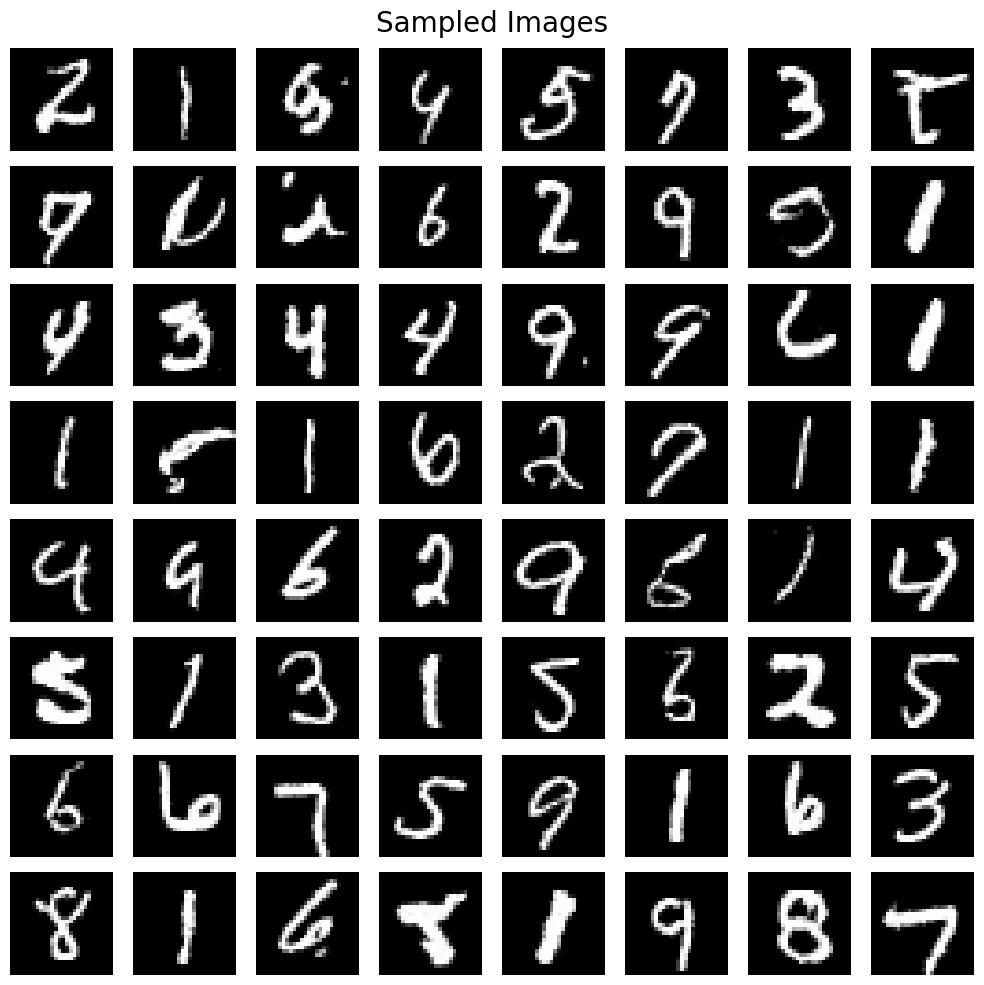

In [8]:
# Sample and save images
sampled_images = diffusion.sample(batch_size=64)

# plot the samples
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sampled_images[i].squeeze().cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.suptitle('Sampled Images', fontsize = 20)
plt.tight_layout()
plt.savefig("plots/sampled_images.png", dpi=300)
plt.show()